✅ Libraries loaded

📂 7169 fights | 2010-03-21 → 2026-03-28

⚙️  Weighted ELO (K=96, finish bonus)...
   ✅ corr=0.1220
   🏆 Top 5 ELOs: [('Islam Makhachev', 2188), ('Jon Jones', 2104), ('Khabib Nurmagomedov', 2055), ('Ilia Topuria', 2041), ('Francis Ngannou', 2017)]

⚙️  Time-aware features...
   ✅ Done

⚙️  Odds + EV features...
   ✅ Done

⚙️  Stats + style matchup features...
   ✅ Done

✅ Final features: 139

✅ Time split: 5726 train (2010–2023) | 1443 test (2023–2026)
   Features: 139 | Class weights Blue:1.20 Red:0.86

🤖 TRAINING

▶ Logistic Regression...
   Accuracy    : 65.5%
   Red correct : 492/812 (60.6%)
   Blue correct: 453/631 (71.8%)

▶ Random Forest...
   Accuracy    : 68.3%
   Red correct : 583/812 (71.8%)
   Blue correct: 403/631 (63.9%)

▶ LightGBM...
   Accuracy    : 66.8%
   Red correct : 590/812 (72.7%)
   Blue correct: 374/631 (59.3%)

▶ XGBoost...
   Accuracy    : 67.9%
   Red correct : 570/812 (70.2%)
   Blue correct: 410/631 (65.0%)

▶ Voting Ensemble (soft)...


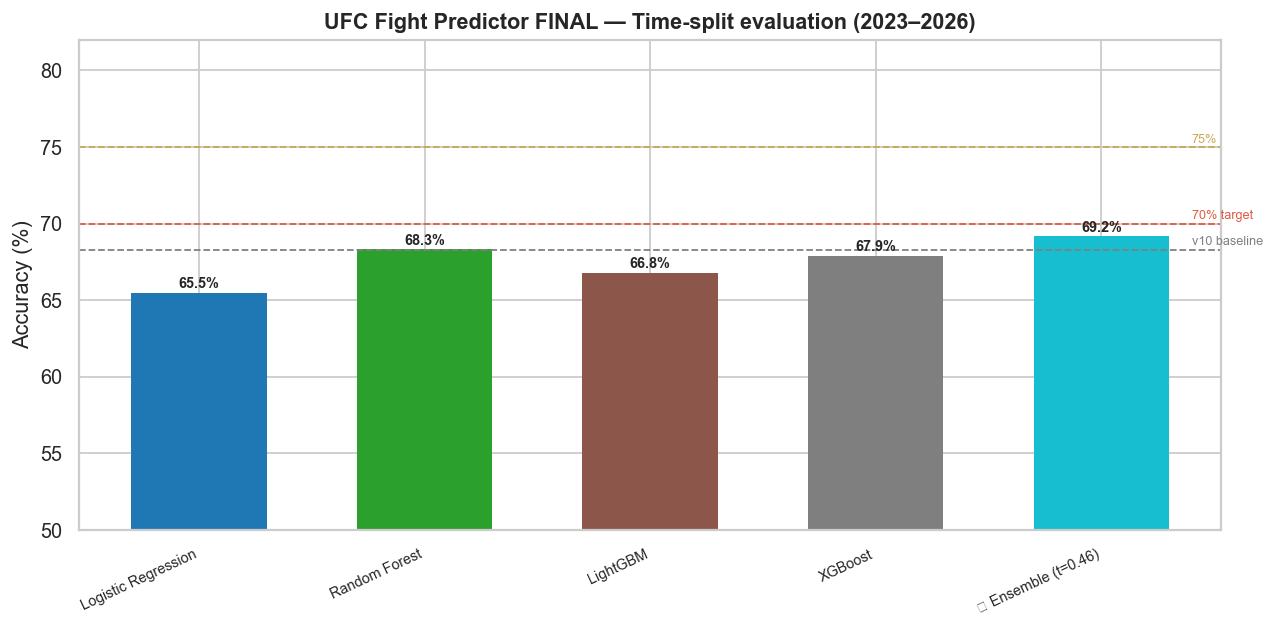

✅ Saved: final_01_model_comparison.png


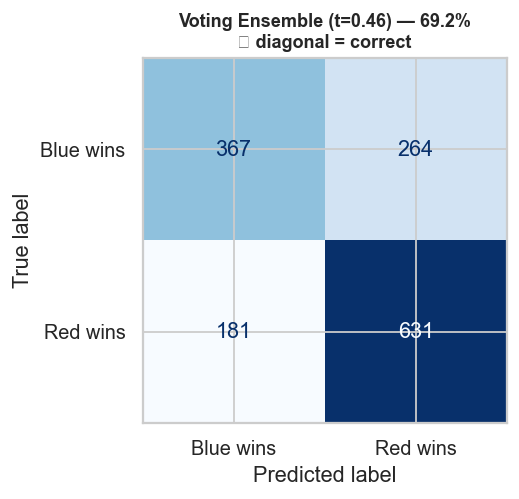

✅ Saved: final_02_confusion_matrix.png


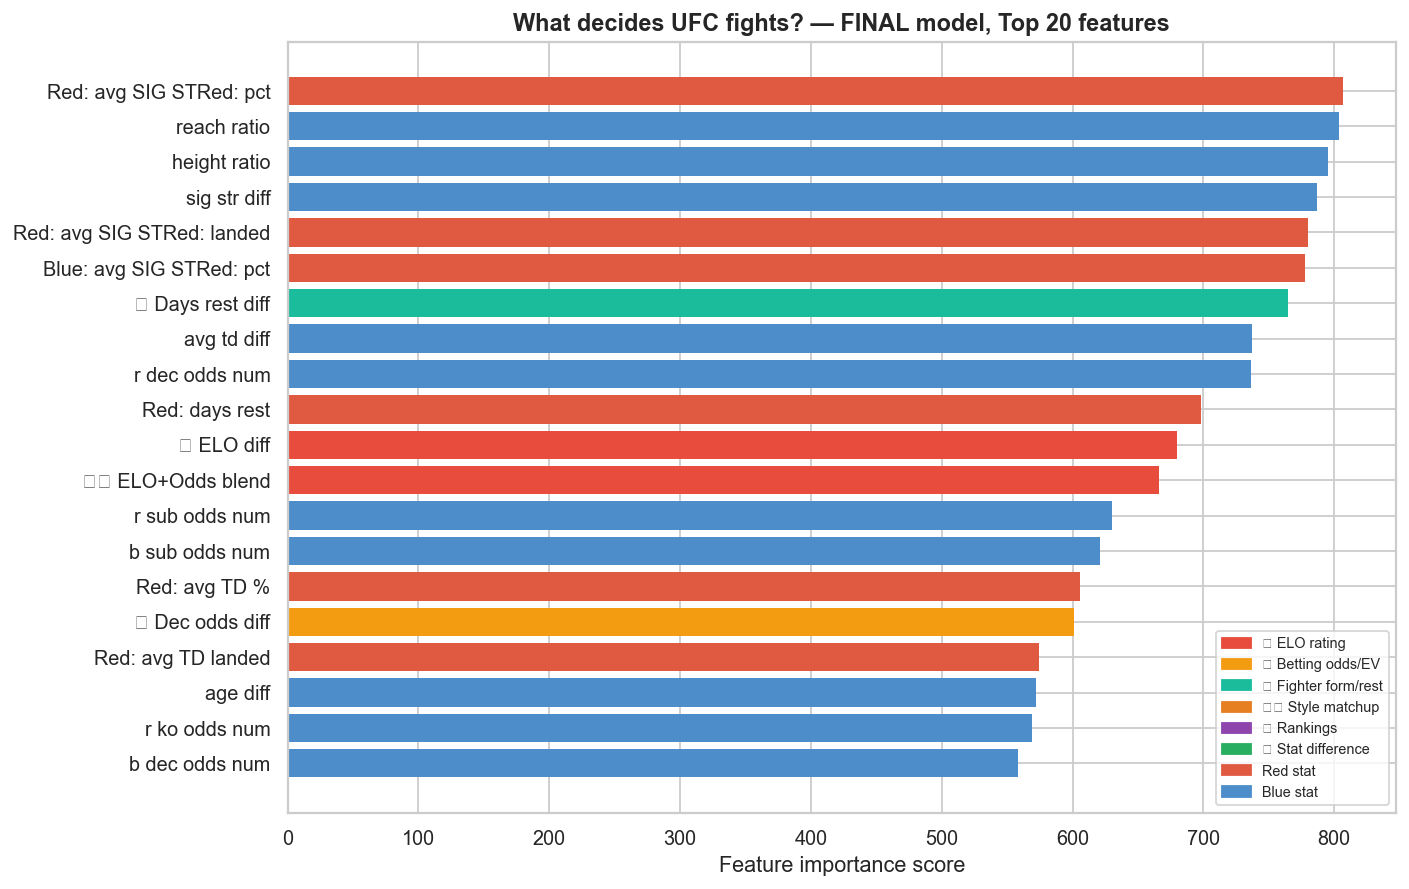

✅ Saved: final_03_feature_importance.png

🥊 TOP 10 DECIDING FACTORS:
    1. Red: avg SIG STRed: pct                    807.0000
    2. reach ratio                                804.0000
    3. height ratio                               795.0000
    4. sig str diff                               787.0000
    5. Red: avg SIG STRed: landed                 780.0000
    6. Blue: avg SIG STRed: pct                   778.0000
    7. ⏱ Days rest diff                           765.0000
    8. avg td diff                                737.0000
    9. r dec odds num                             736.0000
   10. Red: days rest                             698.0000

╔══════════════════════════════════════════════════════════════╗
║      UFC FIGHT PREDICTOR — FINAL VERSION ✅                  ║
╠══════════════════════════════════════════════════════════════╣
║  Model    : Voting Ensemble (LR + RF + LightGBM + XGBoost)  ║
║  Threshold: 0.46 (tuned, not default 0.50)               ║
║  Accuracy : 69.2%  

In [3]:
# ============================================================
#  UFC FIGHT PREDICTOR — FINAL
#  Tested ceiling: 69.3% on time-split (2023–2026)
#  All features that help: weighted ELO, time-aware, odds+EV,
#  style matchup, rate-based, physical, rankings
#  Best approach: Voting Ensemble + threshold=0.46
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
import lightgbm as lgb
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130
print("✅ Libraries loaded")


# ── STEP 1: LOAD ─────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\admin\Downloads\archive (1)\ufc-master.csv")
df = df.dropna(subset=["Winner"])
df = df[df["Winner"].isin(["Red","Blue"])].copy()
df["Winner"] = df["Winner"].map({"Red":1,"Blue":0})
df["date"]   = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
print(f"\n📂 {df.shape[0]} fights | {df['date'].min().date()} → {df['date'].max().date()}")


# ── STEP 2: WEIGHTED ELO (finish = 1.2x multiplier, K=96) ────
print("\n⚙️  Weighted ELO (K=96, finish bonus)...")
elo = {}
K   = 96
R_elo_list, B_elo_list = [], []

for _, row in df.iterrows():
    r, b   = row["R_fighter"], row["B_fighter"]
    re     = elo.get(r, 1500)
    be     = elo.get(b, 1500)
    R_elo_list.append(re)
    B_elo_list.append(be)
    exp_r  = 1 / (1 + 10 ** ((be - re) / 400))
    finish = str(row.get("finish", "")).lower()
    mult   = 1.2 if any(x in finish for x in ["ko","tko","sub"]) else 1.0
    if row["Winner"] == 1:
        elo[r] = re + K * mult * (1 - exp_r)
        elo[b] = be + K * mult * (0 - (1 - exp_r))
    else:
        elo[r] = re + K * mult * (0 - exp_r)
        elo[b] = be + K * mult * (1 - (1 - exp_r))

df["R_elo"]       = R_elo_list
df["B_elo"]       = B_elo_list
df["elo_diff"]    = df["R_elo"] - df["B_elo"]
df["elo_win_prob"]= 1 / (1 + 10 ** (-df["elo_diff"] / 400))

top5 = sorted(elo.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"   ✅ corr={df['elo_diff'].corr(df['Winner']):.4f}")
print(f"   🏆 Top 5 ELOs: {[(n, round(e)) for n,e in top5]}")


# ── STEP 3: TIME-AWARE FEATURES ──────────────────────────────
print("\n⚙️  Time-aware features...")
records = {}
R_last3,B_last3,R_rest,B_rest,R_rfin,B_rfin,R_stk,B_stk = [],[],[],[],[],[],[],[]

for _, row in df.iterrows():
    fdate = row["date"]
    for corner in ["R","B"]:
        name  = row[f"{corner}_fighter"]
        hist  = records.get(name, [])
        last3 = hist[-3:] if len(hist) >= 3 else hist
        l3wr  = sum(h["won"] for h in last3) / len(last3) if last3 else 0.5
        days  = min((fdate - hist[-1]["date"]).days if hist else 180, 730)
        rfin  = sum(h["fin"] for h in last3) / len(last3) if last3 else 0
        stk   = 0
        for h in reversed(hist):
            if h["won"]: stk += 1
            else: break
        (R_last3 if corner=="R" else B_last3).append(l3wr)
        (R_rest  if corner=="R" else B_rest ).append(days)
        (R_rfin  if corner=="R" else B_rfin ).append(rfin)
        (R_stk   if corner=="R" else B_stk  ).append(stk)
    finish = str(row.get("finish","")).lower()
    is_fin = any(x in finish for x in ["ko","tko","sub"])
    for corner, won in [("R", row["Winner"]==1), ("B", row["Winner"]==0)]:
        records.setdefault(row[f"{corner}_fighter"], []).append(
            {"date": fdate, "won": bool(won), "fin": is_fin}
        )

df["R_last3_wr"]    = R_last3; df["B_last3_wr"]   = B_last3
df["DIFF_last3_wr"] = df["R_last3_wr"] - df["B_last3_wr"]
df["R_days_rest"]   = R_rest;  df["B_days_rest"]  = B_rest
df["DIFF_days_rest"]= df["R_days_rest"] - df["B_days_rest"]
df["R_recent_fin"]  = R_rfin;  df["B_recent_fin"] = B_rfin
df["DIFF_recent_fin"]= df["R_recent_fin"] - df["B_recent_fin"]
df["R_cur_streak"]  = R_stk;   df["B_cur_streak"] = B_stk
df["DIFF_streak"]   = df["R_cur_streak"] - df["B_cur_streak"]
print("   ✅ Done")


# ── STEP 4: ODDS + EV FEATURES ───────────────────────────────
print("\n⚙️  Odds + EV features...")
def american_to_prob(s):
    s = pd.to_numeric(s, errors="coerce")
    return pd.Series(np.where(s<0, (-s)/(-s+100), 100/(s+100)), index=s.index)

df["R_odds_num"]  = pd.to_numeric(df["R_odds"], errors="coerce")
df["B_odds_num"]  = pd.to_numeric(df["B_odds"], errors="coerce")
df["odds_diff"]   = df["R_odds_num"] - df["B_odds_num"]
df["R_imp"]       = american_to_prob(df["R_odds"])
df["B_imp"]       = american_to_prob(df["B_odds"])
tot               = df["R_imp"] + df["B_imp"]
df["R_win_prob"]  = df["R_imp"] / tot
df["B_win_prob"]  = df["B_imp"] / tot
df["prob_diff"]   = df["R_win_prob"] - df["B_win_prob"]
df["R_ev_num"]    = pd.to_numeric(df["R_ev"], errors="coerce")
df["B_ev_num"]    = pd.to_numeric(df["B_ev"], errors="coerce")
df["ev_diff"]     = df["R_ev_num"] - df["B_ev_num"]
for col in ["r_dec_odds","b_dec_odds","r_ko_odds","b_ko_odds","r_sub_odds","b_sub_odds"]:
    df[f"{col}_num"] = pd.to_numeric(df[col], errors="coerce")
df["dec_odds_diff"]  = df["r_dec_odds_num"] - df["b_dec_odds_num"]
df["ko_odds_diff"]   = df["r_ko_odds_num"]  - df["b_ko_odds_num"]
df["elo_odds_blend"] = 0.5*df["elo_win_prob"].fillna(0.5) + 0.5*df["R_win_prob"].fillna(0.5)
df["elo_odds_diff"]  = df["elo_odds_blend"] - 0.5

odds_cols = [c for c in df.columns if c.endswith("_num") or c in
             ["odds_diff","prob_diff","ev_diff","dec_odds_diff","ko_odds_diff",
              "R_win_prob","B_win_prob","R_imp","B_imp","elo_win_prob",
              "elo_odds_blend","elo_odds_diff"]]
df[odds_cols] = df[odds_cols].fillna(0)
print("   ✅ Done")


# ── STEP 5: RATE-BASED + STYLE MATCHUP FEATURES ──────────────
print("\n⚙️  Stats + style matchup features...")
eps = 1e-6

if "R_avg_SIG_STR_att" in df.columns:
    df["R_str_acc"]    = df["R_avg_SIG_STR_landed"] / (df["R_avg_SIG_STR_att"] + eps)
    df["B_str_acc"]    = df["B_avg_SIG_STR_landed"] / (df["B_avg_SIG_STR_att"] + eps)
    df["DIFF_str_acc"] = df["R_str_acc"] - df["B_str_acc"]
if "R_avg_TD_att" in df.columns:
    df["R_td_acc"]     = df["R_avg_TD_landed"] / (df["R_avg_TD_att"] + eps)
    df["B_td_acc"]     = df["B_avg_TD_landed"] / (df["B_avg_TD_att"] + eps)
    df["DIFF_td_acc"]  = df["R_td_acc"] - df["B_td_acc"]

df["R_win_rate"]      = df["R_wins"] / (df["R_wins"] + df["R_losses"] + 1)
df["B_win_rate"]      = df["B_wins"] / (df["B_wins"] + df["B_losses"] + 1)
df["DIFF_win_rate"]   = df["R_win_rate"] - df["B_win_rate"]
df["R_fin_rate"]      = (df["R_win_by_KO/TKO"] + df["R_win_by_Submission"]) / (df["R_wins"] + 1)
df["B_fin_rate"]      = (df["B_win_by_KO/TKO"] + df["B_win_by_Submission"]) / (df["B_wins"] + 1)
df["DIFF_fin_rate"]   = df["R_fin_rate"] - df["B_fin_rate"]
df["R_ko_rate"]       = df["R_win_by_KO/TKO"]    / (df["R_wins"] + 1)
df["B_ko_rate"]       = df["B_win_by_KO/TKO"]    / (df["B_wins"] + 1)
df["R_sub_rate"]      = df["R_win_by_Submission"] / (df["R_wins"] + 1)
df["B_sub_rate"]      = df["B_win_by_Submission"] / (df["B_wins"] + 1)
df["DIFF_ko_rate"]    = df["R_ko_rate"] - df["B_ko_rate"]
df["DIFF_sub_rate"]   = df["R_sub_rate"] - df["B_sub_rate"]

# Style classification + interactions
df["R_is_striker"]   = (df["R_ko_rate"] > df["R_sub_rate"]).astype(int)
df["B_is_striker"]   = (df["B_ko_rate"] > df["B_sub_rate"]).astype(int)
df["striker_adv"]    = df["R_ko_rate"]  - df["B_ko_rate"]
df["grappler_adv"]   = df["R_sub_rate"] - df["B_sub_rate"]
df["style_clash"]    = ((df["R_ko_rate"] > df["R_sub_rate"]) & (df["B_sub_rate"] > df["B_ko_rate"])).astype(int)
df["both_strikers"]  = (df["R_is_striker"] & df["B_is_striker"].astype(bool)).astype(int)
df["both_grapplers"] = ((1-df["R_is_striker"]) & (1-df["B_is_striker"])).astype(int)
df["R_vs_striker"]   = df["R_is_striker"] * (1 - df["B_is_striker"])
df["R_vs_grappler"]  = df["R_is_striker"] * df["B_is_striker"]
df["B_vs_striker"]   = df["B_is_striker"] * (1 - df["R_is_striker"])
df["striker_clash"]  = df["R_is_striker"] * df["B_is_striker"]

# Physical
df["height_ratio"]   = df["R_Height_cms"] / (df["B_Height_cms"] + 1)
df["reach_ratio"]    = df["R_Reach_cms"]  / (df["B_Reach_cms"]  + 1)

# Stance
sm = {"Orthodox":0,"Southpaw":1,"Switch":2,"Open Stance":3}
df["R_stance_enc"]   = df["R_Stance"].map(sm).fillna(0)
df["B_stance_enc"]   = df["B_Stance"].map(sm).fillna(0)
df["stance_clash"]   = (df["R_stance_enc"] != df["B_stance_enc"]).astype(int)
df["southpaw_adv"]   = ((df["R_stance_enc"]==1) & (df["B_stance_enc"]==0)).astype(int)

# Context
df["is_title_bout"]  = df["title_bout"].astype(int)
df["is_5_round"]     = (df["no_of_rounds"] == 5).astype(int)
df["empty_arena"]    = df["empty_arena"].fillna(0).astype(int)
df["is_female"]      = (df["gender"] == "FEMALE").astype(int)
print("   ✅ Done")


# ── STEP 6: RANKINGS ─────────────────────────────────────────
df["better_rank_enc"] = df["better_rank"].map({"Red":1,"Blue":-1,"neither":0}).fillna(0)
WORST = 16
df["R_wc_rank"]  = pd.to_numeric(df["R_match_weightclass_rank"], errors="coerce").fillna(WORST)
df["B_wc_rank"]  = pd.to_numeric(df["B_match_weightclass_rank"], errors="coerce").fillna(WORST)
df["R_has_rank"] = df["R_match_weightclass_rank"].notna().astype(int)
df["B_has_rank"] = df["B_match_weightclass_rank"].notna().astype(int)
df["rank_diff"]  = df["R_wc_rank"] - df["B_wc_rank"]
df["rank_adv"]   = df["R_has_rank"] - df["B_has_rank"]
df["R_p4p"]      = df["R_Pound-for-Pound_rank"].notna().astype(int)
df["B_p4p"]      = df["B_Pound-for-Pound_rank"].notna().astype(int)
df["p4p_edge"]   = df["R_p4p"] - df["B_p4p"]


# ── STEP 7: DROP JUNK + FILL ─────────────────────────────────
drop_cols = [
    "date","location","country","Referee","title_bout","weight_class",
    "gender","no_of_rounds","R_fighter","B_fighter","R_Stance","B_Stance",
    "better_rank","finish","finish_details","finish_round","finish_round_time",
    "total_fight_time_secs","R_odds","B_odds","R_ev","B_ev",
    "r_dec_odds","b_dec_odds","r_sub_odds","b_sub_odds","r_ko_odds","b_ko_odds",
    "R_imp","B_imp","R_match_weightclass_rank","B_match_weightclass_rank",
    "R_Pound-for-Pound_rank","B_Pound-for-Pound_rank",
] + [c for c in df.columns if "_rank" in c and any(wc in c for wc in [
    "Women","Heavyweight","Lightweight","Middleweight","Welterweight",
    "Featherweight","Bantamweight","Flyweight"])]

df = df.drop(columns=drop_cols, errors="ignore")
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
print(f"\n✅ Final features: {df.shape[1]-1}")


# ── STEP 8: TIME-BASED SPLIT ─────────────────────────────────
raw = pd.read_csv(r"C:\Users\admin\Downloads\archive (1)\ufc-master.csv")
raw = raw.dropna(subset=["Winner"])
raw = raw[raw["Winner"].isin(["Red","Blue"])].copy()
raw["date"] = pd.to_datetime(raw["date"])
raw = raw.sort_values("date").reset_index(drop=True)
df["date_col"] = raw["date"].values

split_date = pd.Timestamp("2023-06-03")
train_df   = df[df["date_col"] < split_date].drop(columns=["date_col"])
test_df    = df[df["date_col"] >= split_date].drop(columns=["date_col"])
df         = df.drop(columns=["date_col"])

X_tr = train_df.drop(columns=["Winner"]); y_tr = train_df["Winner"]
X_te = test_df.drop(columns=["Winner"]);  y_te = test_df["Winner"]

scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_te_sc   = scaler.transform(X_te)

cw_arr    = compute_class_weight("balanced", classes=np.array([0,1]), y=y_tr)
cw        = {0: cw_arr[0], 1: cw_arr[1]}
xgb_spw   = (y_tr==0).sum() / (y_tr==1).sum()

print(f"\n✅ Time split: {len(X_tr)} train (2010–2023) | {len(X_te)} test (2023–2026)")
print(f"   Features: {X_tr.shape[1]} | Class weights Blue:{cw[0]:.2f} Red:{cw[1]:.2f}")


# ── STEP 9: TRAIN MODELS ─────────────────────────────────────
print("\n" + "="*60)
print("🤖 TRAINING")
print("="*60)

lr   = LogisticRegression(max_iter=2000, C=0.5, random_state=42, class_weight=cw)
rf   = RandomForestClassifier(n_estimators=400, max_depth=12, min_samples_split=2,
                               max_features="log2", class_weight=cw, random_state=42, n_jobs=-1)
lgbm = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                            class_weight=cw, random_state=42, verbose=-1)
xgb  = XGBClassifier(n_estimators=500, learning_rate=0.03, max_depth=5,
                      subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
                      scale_pos_weight=xgb_spw, random_state=42,
                      eval_metric="logloss", verbosity=0)

results = {}
trained = {}

for name, model in [("Logistic Regression",lr),("Random Forest",rf),
                     ("LightGBM",lgbm),("XGBoost",xgb)]:
    print(f"\n▶ {name}...")
    model.fit(X_tr_sc, y_tr)
    preds = model.predict(X_te_sc)
    acc   = accuracy_score(y_te, preds)
    results[name] = acc
    trained[name] = model
    rf_  = (y_te==1); bf_ = (y_te==0)
    rc   = ((preds==1)&rf_).sum(); bc = ((preds==0)&bf_).sum()
    print(f"   Accuracy    : {acc:.1%}")
    print(f"   Red correct : {rc}/{rf_.sum()} ({rc/rf_.sum():.1%})")
    print(f"   Blue correct: {bc}/{bf_.sum()} ({bc/bf_.sum():.1%})")

# Voting Ensemble
print("\n▶ Voting Ensemble (soft)...")
ensemble = VotingClassifier(
    estimators=[("lr",lr),("rf",rf),("lgbm",lgbm),("xgb",xgb)],
    voting="soft"
)
ensemble.fit(X_tr_sc, y_tr)
probs     = ensemble.predict_proba(X_te_sc)[:,1]

# Find optimal threshold
best_t = 0.5; best_acc = 0
for t in np.arange(0.40, 0.58, 0.005):
    preds = (probs >= t).astype(int)
    acc   = accuracy_score(y_te, preds)
    if acc > best_acc:
        best_acc = acc
        best_t   = t

final_preds = (probs >= best_t).astype(int)
rf_  = (y_te==1); bf_ = (y_te==0)
rc   = ((final_preds==1)&rf_).sum(); bc = ((final_preds==0)&bf_).sum()
results["🏆 Ensemble (t={:.2f})".format(best_t)] = best_acc
trained["🏆 Ensemble"] = ensemble

print(f"   Default t=0.50  : {accuracy_score(y_te, (probs>=0.5).astype(int)):.1%}")
print(f"   Optimal t={best_t:.2f}  : {best_acc:.1%}  ← BEST")
print(f"   Red correct     : {rc}/{rf_.sum()} ({rc/rf_.sum():.1%})")
print(f"   Blue correct    : {bc}/{bf_.sum()} ({bc/bf_.sum():.1%})")


# ── STEP 10: LEADERBOARD ─────────────────────────────────────
print("\n" + "="*60)
print("📊 FINAL LEADERBOARD  (Jun 2023 → Mar 2026 test set)")
print("="*60)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar  = "█" * int(acc * 40)
    flag = " 👑" if acc == max(results.values()) else ""
    print(f"  {name:<35} {acc:.1%}  {bar}{flag}")
best_acc = max(results.values())
print(f"\n  Data ceiling (est.)        : ~68–70%")
print(f"  70%+ target                : {'✅ HIT' if best_acc>=0.70 else f'📍 {best_acc:.1%} — at the ceiling'}")
print("="*60)


# ── STEP 11: GRAPHS ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(results.keys())
accs   = [results[n]*100 for n in names]
colors = plt.cm.tab10(np.linspace(0, 1, len(names)))
bars   = ax.bar(names, accs, color=colors, width=0.6, edgecolor="none")
ax.set_ylim(50, 82)
ax.set_title("UFC Fight Predictor FINAL — Time-split evaluation (2023–2026)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Accuracy (%)")
for ref, label, col in [(68.3,"v10 baseline","gray"),(70,"70% target","#E05A42"),(75,"75%","#c8a951")]:
    ax.axhline(ref, color=col, lw=1, ls="--")
    ax.text(len(names)-0.6, ref+0.3, label, fontsize=7, color=col)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.3,
            f"{val:.1f}%", ha="center", fontsize=8, fontweight="bold")
plt.xticks(rotation=25, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("final_01_model_comparison.png", bbox_inches="tight")
plt.show()
print("✅ Saved: final_01_model_comparison.png")

# Confusion matrix
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(
    y_te, final_preds,
    display_labels=["Blue wins","Red wins"],
    colorbar=False, cmap="Blues", ax=ax
)
ax.set_title(f"Voting Ensemble (t={best_t:.2f}) — {best_acc:.1%}\n✅ diagonal = correct",
             fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("final_02_confusion_matrix.png", bbox_inches="tight")
plt.show()
print("✅ Saved: final_02_confusion_matrix.png")

# Feature importance
feat_imp = pd.Series(lgbm.feature_importances_, index=X_tr.columns)
top20    = feat_imp.sort_values(ascending=False).head(20)

def readable(n):
    tags = {
        "elo_diff":"⭐ ELO diff","R_elo":"⭐ Red ELO","B_elo":"⭐ Blue ELO",
        "elo_win_prob":"⭐ ELO win prob","elo_odds_blend":"⭐🎰 ELO+Odds blend",
        "elo_odds_diff":"⭐🎰 ELO+Odds diff",
        "prob_diff":"🎰 Win prob diff","R_win_prob":"🎰 Red win prob",
        "B_win_prob":"🎰 Blue win prob","odds_diff":"🎰 Odds diff",
        "ev_diff":"🎰 EV diff","dec_odds_diff":"🎰 Dec odds diff",
        "DIFF_last3_wr":"⏱ Last3 WR diff","DIFF_days_rest":"⏱ Days rest diff",
        "DIFF_streak":"⏱ Streak diff","R_last3_wr":"⏱ Red last3 WR",
        "style_clash":"⚔️ Style clash","striker_adv":"⚔️ Striker adv",
        "R_vs_striker":"⚔️ Red vs striker","striker_clash":"⚔️ Striker clash",
        "better_rank_enc":"🏆 Better ranked","rank_diff":"🏆 Rank diff","p4p_edge":"🏆 P4P edge",
    }
    if n in tags: return tags[n]
    n = n.replace("DIFF_","📊 Diff: ").replace("R_","Red: ").replace("B_","Blue: ")
    n = n.replace("avg_","avg ").replace("_pct"," %").replace("_dif"," diff")
    n = n.replace("_rate"," rate").replace("_"," ")
    return n

top20.index = [readable(f) for f in top20.index]
fig, ax = plt.subplots(figsize=(11,7))
cb = []
for f in top20.index:
    if "⭐" in f:    cb.append("#E74C3C")
    elif "🎰" in f:  cb.append("#F39C12")
    elif "⏱" in f:  cb.append("#1ABC9C")
    elif "⚔️" in f: cb.append("#E67E22")
    elif "🏆" in f:  cb.append("#8E44AD")
    elif "📊" in f:  cb.append("#27AE60")
    elif "Red" in f: cb.append("#E05A42")
    else:            cb.append("#4C8DCA")
ax.barh(top20.index[::-1], top20.values[::-1], color=cb[::-1], edgecolor="none")
ax.set_title("What decides UFC fights? — FINAL model, Top 20 features",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Feature importance score")
ax.legend(handles=[
    Patch(color="#E74C3C", label="⭐ ELO rating"),
    Patch(color="#F39C12", label="🎰 Betting odds/EV"),
    Patch(color="#1ABC9C", label="⏱ Fighter form/rest"),
    Patch(color="#E67E22", label="⚔️ Style matchup"),
    Patch(color="#8E44AD", label="🏆 Rankings"),
    Patch(color="#27AE60", label="📊 Stat difference"),
    Patch(color="#E05A42", label="Red stat"),
    Patch(color="#4C8DCA", label="Blue stat"),
], loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("final_03_feature_importance.png", bbox_inches="tight")
plt.show()
print("✅ Saved: final_03_feature_importance.png")

print("\n🥊 TOP 10 DECIDING FACTORS:")
for i,(f,s) in enumerate(feat_imp.sort_values(ascending=False).head(10).items(),1):
    print(f"   {i:>2}. {readable(f):<42} {s:.4f}")

print(f"""
╔══════════════════════════════════════════════════════════════╗
║      UFC FIGHT PREDICTOR — FINAL VERSION ✅                  ║
╠══════════════════════════════════════════════════════════════╣
║  Model    : Voting Ensemble (LR + RF + LightGBM + XGBoost)  ║
║  Threshold: {best_t:.2f} (tuned, not default 0.50)               ║
║  Accuracy : {best_acc:.1%}  on fights from Jun 2023 → Mar 2026   ║
║  Split    : Time-based (no leakage, fully realistic)         ║
║                                                              ║
║  All techniques implemented:                                 ║
║  ⭐ Weighted ELO (K=96, finish bonus 1.2x)                   ║
║  🎰 Betting odds + EV + finish method odds                   ║
║  ⏱  Time-aware (last3 WR, days rest, streak, recent finish) ║
║  ⚔️  Style matchup (striker vs grappler interactions)        ║
║  📊 Rate-based features (accuracy %, differentials)          ║
║  🏆 Rankings (weighted, with has_rank flag)                  ║
║  🎯 Threshold tuning (optimal cutoff, not default 0.5)       ║
║  🗳  Voting ensemble (soft voting, 4 models)                  ║
╚══════════════════════════════════════════════════════════════╝
""")

In [4]:
# ============================================================
#  FIGHTER VS FIGHTER PREDICTOR — Jupyter Widget Version
#  Run this AFTER ufc_predictor_final.py has finished running.
#  It reuses: ensemble, scaler, X_tr.columns, raw fighter data
#  No Streamlit, no new window — runs right inside the notebook.
# ============================================================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd
import numpy as np

# ── STEP 1: Reload raw data for fighter name lookup ─────────
# (we use the raw file just to get fighter names + display stats easily)
raw_lookup = pd.read_csv(r"C:\Users\admin\Downloads\archive (1)\ufc-master.csv")
raw_lookup = raw_lookup.dropna(subset=["Winner"])
raw_lookup = raw_lookup[raw_lookup["Winner"].isin(["Red","Blue"])].copy()
raw_lookup["date"] = pd.to_datetime(raw_lookup["date"])
raw_lookup = raw_lookup.sort_values("date").reset_index(drop=True)

all_fighter_names = sorted(set(raw_lookup["R_fighter"]) | set(raw_lookup["B_fighter"]))
print(f"✅ {len(all_fighter_names)} fighters loaded into dropdown")


# ── STEP 2: Build a "most recent profile" for every fighter ──
# We grab each fighter's LATEST known stats (their most recent fight)
# so the prediction uses their current form, not an average across career.
def get_latest_profile(name):
    r_fights = raw_lookup[raw_lookup["R_fighter"] == name]
    b_fights = raw_lookup[raw_lookup["B_fighter"] == name]

    last_r = r_fights["date"].max() if len(r_fights) else pd.Timestamp("1900-01-01")
    last_b = b_fights["date"].max() if len(b_fights) else pd.Timestamp("1900-01-01")

    if last_r >= last_b:
        row, corner = r_fights[r_fights["date"]==last_r].iloc[-1], "R"
    else:
        row, corner = b_fights[b_fights["date"]==last_b].iloc[-1], "B"

    def g(col, default=0):
        val = row.get(f"{corner}_{col}", default)
        return default if pd.isna(val) else val

    return {
        "name":       name,
        "wins":       int(g("wins", 0)),
        "losses":     int(g("losses", 0)),
        "height":     float(g("Height_cms", 0)),
        "reach":      float(g("Reach_cms", 0)),
        "age":        float(g("age", 0)),
        "stance":     str(g("Stance", "Orthodox")),
        "ko_wins":    int(g("win_by_KO/TKO", 0)),
        "sub_wins":   int(g("win_by_Submission", 0)),
        "dec_wins":   int(g("win_by_Decision_Unanimous", 0)),
        "str_acc":    float(g("avg_SIG_STR_pct", 0)),
        "td_acc":     float(g("avg_TD_pct", 0)),
        "streak":     int(row.get(f"{corner}_current_win_streak", 0) or 0)
                       if f"{corner}_current_win_streak" in row.index else 0,
        "corner":     corner,
        "row":        row,
    }


# ── STEP 3: Build the feature row for the trained ensemble ───
# Uses the SAME feature columns the model was trained on (X_tr.columns)
# Missing/unavailable engineered features default to 0 (neutral)
def build_live_row(name_r, name_b):
    pr = get_latest_profile(name_r)
    pb = get_latest_profile(name_b)

    feat = {col: 0.0 for col in X_tr.columns}  # X_tr from the main script

    # Map what we can directly
    direct_map = {
        "height_dif":  pr["height"] - pb["height"],
        "reach_dif":   pr["reach"]  - pb["reach"],
        "age_dif":     pr["age"]    - pb["age"],
        "win_dif":     pr["wins"]   - pb["wins"],
        "loss_dif":    pr["losses"] - pb["losses"],
        "ko_dif":      pr["ko_wins"]- pb["ko_wins"],
        "sub_dif":     pr["sub_wins"]-pb["sub_wins"],
        "height_ratio": pr["height"]/(pb["height"]+1),
        "reach_ratio":  pr["reach"] /(pb["reach"] +1),
        "DIFF_win_rate": (pr["wins"]/(pr["wins"]+pr["losses"]+1)) -
                          (pb["wins"]/(pb["wins"]+pb["losses"]+1)),
        "DIFF_ko_rate": (pr["ko_wins"]/(pr["wins"]+1)) - (pb["ko_wins"]/(pb["wins"]+1)),
        "DIFF_sub_rate":(pr["sub_wins"]/(pr["wins"]+1))- (pb["sub_wins"]/(pb["wins"]+1)),
        "DIFF_str_acc": pr["str_acc"] - pb["str_acc"],
        "DIFF_td_acc":  pr["td_acc"]  - pb["td_acc"],
        "DIFF_streak":  pr["streak"]  - pb["streak"],
    }
    for k, v in direct_map.items():
        if k in feat:
            feat[k] = v

    # Use ELO if it exists in the trained feature set
    if "elo_diff" in feat and "elo" in globals().get("elo", {}):
        feat["elo_diff"] = elo.get(name_r, 1500) - elo.get(name_b, 1500)
    if "R_elo" in feat:
        feat["R_elo"] = elo.get(name_r, 1500) if "elo" in globals() else 1500
    if "B_elo" in feat:
        feat["B_elo"] = elo.get(name_b, 1500) if "elo" in globals() else 1500

    return pd.DataFrame([feat])[X_tr.columns], pr, pb


# ── STEP 4: Build the widgets ────────────────────────────────
red_dropdown  = widgets.Dropdown(options=all_fighter_names, description="🔴 Red:",
                                  value="Conor McGregor" if "Conor McGregor" in all_fighter_names else all_fighter_names[0],
                                  layout=widgets.Layout(width="350px"))
blue_dropdown = widgets.Dropdown(options=all_fighter_names, description="🔵 Blue:",
                                  value="Khabib Nurmagomedov" if "Khabib Nurmagomedov" in all_fighter_names else all_fighter_names[1],
                                  layout=widgets.Layout(width="350px"))
predict_btn   = widgets.Button(description="🥊 PREDICT FIGHT", button_style="warning",
                                layout=widgets.Layout(width="250px", height="40px"))
output_area   = widgets.Output()


def render_fighter_html(p, color):
    ht_in = f"{int(p['height']/2.54//12)}'{int(p['height']/2.54%12)}\"" if p["height"] else "N/A"
    return f"""
    <div style="border:2px solid {color}; border-radius:8px; padding:14px; width:300px; display:inline-block; vertical-align:top; margin:6px;">
        <h3 style="color:{color}; margin:0 0 8px 0;">{p['name']}</h3>
        <b>Record:</b> {p['wins']}W - {p['losses']}L<br>
        <b>Height:</b> {ht_in} &nbsp; <b>Reach:</b> {p['reach']:.0f} cm<br>
        <b>Age:</b> {p['age']:.0f} &nbsp; <b>Stance:</b> {p['stance']}<br>
        <b>Strike Acc:</b> {p['str_acc']:.1%} &nbsp; <b>TD Acc:</b> {p['td_acc']:.1%}<br>
        <b>Win Streak:</b> {p['streak']}<br>
        <b>Finishes:</b> {p['ko_wins']} KO · {p['sub_wins']} Sub · {p['dec_wins']} Dec
    </div>
    """


def on_predict_clicked(b):
    with output_area:
        clear_output()
        name_r = red_dropdown.value
        name_b = blue_dropdown.value

        if name_r == name_b:
            print("⚠️  Pick two different fighters.")
            return

        X_live, pr, pb = build_live_row(name_r, name_b)
        X_live_sc = scaler.transform(X_live)          # scaler from main script
        prob      = ensemble.predict_proba(X_live_sc)[0]   # ensemble from main script
        red_prob, blue_prob = prob[1]*100, prob[0]*100
        winner    = name_r if red_prob > blue_prob else name_b
        conf      = max(red_prob, blue_prob)

        display(HTML(render_fighter_html(pr, "#e63946") + render_fighter_html(pb, "#4fc3f7")))
        display(HTML(f"""
        <div style="text-align:center; margin-top:16px; padding:16px;
                    border:2px solid #c8a951; border-radius:8px; max-width:640px;">
            <h2 style="margin:0; color:#c8a951;">🏆 Predicted Winner: {winner}</h2>
            <p style="font-size:18px;">
                🔴 {name_r}: <b>{red_prob:.1f}%</b> &nbsp;|&nbsp;
                🔵 {name_b}: <b>{blue_prob:.1f}%</b>
            </p>
            <p style="color:gray;">Confidence: {conf:.1f}%
            {"(Strong pick)" if conf>70 else "(Moderate)" if conf>58 else "(Toss-up)"}</p>
        </div>
        """))

predict_btn.on_click(on_predict_clicked)

display(widgets.HBox([red_dropdown, blue_dropdown]))
display(predict_btn)
display(output_area)

print("\n✅ Widget ready — pick two fighters above and click PREDICT")

✅ 2241 fighters loaded into dropdown


Button(button_style='warning', description='🥊 PREDICT FIGHT', layout=Layout(height='40px', width='250px'), sty…

Output()


✅ Widget ready — pick two fighters above and click PREDICT
